# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Calabozo, Nicolas Daniel
- Alumno 2 : Lapolla, Martín Facundo

## Librerías

In [100]:
# --- Librerías estándar --
import os
import numpy as np
import cv2
import ssl
import time
import uuid
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import copy
from tqdm import tqdm
from collections import Counter

# -- PyTorch y librerías relacionadas --
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from torchvision import datasets
from facenet_pytorch import MTCNN, InceptionResnetV1

# -- Scikit-learn --
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances 

# -- Configuración para evitar problemas de SSL al descargar el dataset --
ssl._create_default_https_context = ssl._create_unverified_context

# -- Importación de clases personalizadas para el manejo de base de datos vectorial --
import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

#-- Cargar variables de entorno --
load_dotenv(dotenv_path="./src/.env")

# -- Configuración del dispositivo (GPU si está disponible, sino CPU) --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


Para poder interactuar con la base de datos vectorial (PGVector), necesitamos crear una instancia de la clase provista por la cátedra PgVectorEmbeddingStore. Para ello, recuperamos los valores de inicialización desde el entorno de desarrollo (.env)

In [78]:
#Setup de BBDD vectorial 
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB","faces"),
    user=os.getenv("POSTGRES_USER", "faces_user"),
    password=os.getenv("POSTGRES_PASSWORD", "faces_pass"),
    host=os.getenv("POSTGRES_HOST", "localhost"),
    port=int(os.getenv("POSTGRES_PORT", "5432")),
    embedding_dim=int(os.getenv("EMBEDDING_DIM", 512))
)

### 1. Preprocesamiento

#### Dataset LFW (Labelled Faces in the Wild)

Seleccionamos LFW (Labelled Faces in The Wild) como dataset complementario al propio, ya que su propósito se alinea con el nuestro, fue creado para realizar proyectos orientados al reconocimiento facial y etiquetado de las mismas mediante diferentes modelos basados en redes neuronales o transformers.

In [79]:
# -- Descarga del dataset LFW (Labeled Faces in the Wild) --
lfw_data = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
    resize=1.0,
    slice_=None, #type: ignore
    download_if_missing=True)
print("Descarga completa - Imágenes sin recortar, a color, tamaño 250x250")


Descarga completa - Imágenes sin recortar, a color, tamaño 250x250


--------------------------------------------------
RESUMEN ESTADÍSTICO: LFW (min_faces_per_person=20)
--------------------------------------------------
Total de imágenes:          3023
Total de clases (personas): 62
Promedio de fotos/persona:  48.76
Desviación Estándar:        70.51
Mínimo de fotos/persona:    20
Máximo de fotos/persona:    530
--------------------------------------------------

ANÁLISIS DE DESBALANCE:
Persona                   | Fotos
-----------------------------------
George W Bush             | 530   (Clase Mayoritaria)
Colin Powell              | 236   (Clase Mayoritaria)
Tony Blair                | 144   (Clase Mayoritaria)
Donald Rumsfeld           | 121   (Clase Mayoritaria)
Gerhard Schroeder         | 109   (Clase Mayoritaria)
...
Angelina Jolie            | 20    (Clase Minoritaria)
Jiang Zemin               | 20    (Clase Minoritaria)
Igor Ivanov               | 20    (Clase Minoritaria)
Michael Bloomberg         | 20    (Clase Minoritaria)
Paul Bremer     

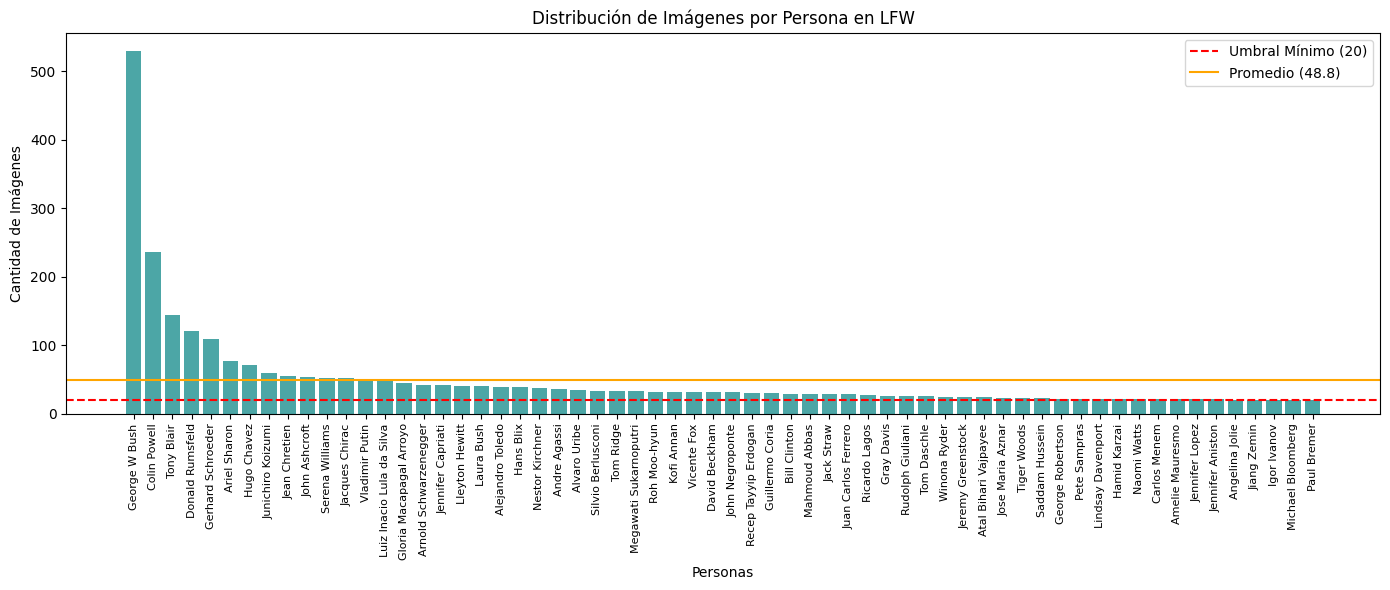

In [104]:
#Calcular frecuencias de cada persona
counts = Counter(lfw_data.target) #type: ignore
names = lfw_data.target_names #type: ignore

#Mapear nombres a sus conteos y ordenar de mayor a menor
class_counts = {names[i]: count for i, count in counts.items()}
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

#Cálculo de Medidas Resumen
total_images = len(lfw_data.images) #type: ignore
total_classes = len(names)
counts_val = list(counts.values())
min_imgs = np.min(counts_val)
max_imgs = np.max(counts_val)
mean_imgs = np.mean(counts_val)
std_imgs = np.std(counts_val)

#Reporte
print("-" * 50)
print(f"RESUMEN ESTADÍSTICO: LFW (min_faces_per_person=20)")
print("-" * 50)
print(f"Total de imágenes:          {total_images}")
print(f"Total de clases (personas): {total_classes}")
print(f"Promedio de fotos/persona:  {mean_imgs:.2f}")
print(f"Desviación Estándar:        {std_imgs:.2f}")
print(f"Mínimo de fotos/persona:    {min_imgs}")
print(f"Máximo de fotos/persona:    {max_imgs}")
print("-" * 50)

print("\nANÁLISIS DE DESBALANCE:")
print(f"{'Persona':<25} | {'Fotos':<5}")
print("-" * 35)
for name, count in sorted_counts[:5]:
    print(f"{name:<25} | {count:<5} (Clase Mayoritaria)")
print("...")
for name, count in sorted_counts[-5:]:
    print(f"{name:<25} | {count:<5} (Clase Minoritaria)")

# 5. Visualización de la Distribución
plt.figure(figsize=(14, 6))
labels, values = zip(*sorted_counts)
plt.bar(labels, values, color='teal', alpha=0.7)
plt.axhline(y=20, color='red', linestyle='--', label='Umbral Mínimo (20)')
plt.axhline(y=float(mean_imgs), color='orange', linestyle='-', label=f'Promedio ({mean_imgs:.1f})')

plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Personas')
plt.ylabel('Cantidad de Imágenes')
plt.title('Distribución de Imágenes por Persona en LFW')
plt.legend()
plt.tight_layout()

Ya que hay un desbalance de clases notorio, decidimos realizar un undersampling, quedándonos solamente con veinte fotos por clase

In [80]:
np.random.seed(42)

max_ph_per_person = 20
balanced_idx = []

# Obtenemos todos los identificadores únicos (IDs numéricos)
unique_classes = np.unique(lfw_data.target) #type: ignore

for class_ in unique_classes:
    #Encontramos todos los índices donde aparece la persona
    class_idx = np.where(lfw_data.target == class_)[0] #type: ignore
    
    #Si la persona tiene más de 20 fotos, aplicamos undersampling
    if len(class_idx) > max_ph_per_person:
        #Elegimos 20 índices al azar
        selected_idx = np.random.choice(class_idx, max_ph_per_person, replace=False)
    else:
        #Si tiene 20 o menos, nos quedamos con todas.
        #Como explicitamos mediante el método lfw_fetch_people que queremos personas con al menos 20 fotos, esto no debería pasar
        selected_idx = class_idx
        
    #Guardamos los índices seleccionados para la persona
    balanced_idx.extend(selected_idx)

#Convertimos la lista a un arreglo de numpy
balanced_idx = np.array(balanced_idx)

# Mezclamos los índices finales. 
# Si no lo hacemos, el dataset quedará ordenado por persona, lo cual es malo para el entrenamiento.
np.random.shuffle(balanced_idx)

#Filtramos los arreglos originales usando los nuevos índices
balanced_imgs = lfw_data.images[balanced_idx] #type: ignore
balanced_labels = lfw_data.target[balanced_idx] #type: ignore

# Resumen
print(f"Total de imágenes original: {len(lfw_data.images)}") #type: ignore
print(f"Total de imágenes balanceado: {len(balanced_imgs)}")

# Verificación
_, counts = np.unique(balanced_labels, return_counts=True)
print(f"Máximo de fotos para una persona ahora: {counts.max()}")

Total de imágenes original: 3023
Total de imágenes balanceado: 1240
Máximo de fotos para una persona ahora: 20


In [81]:
#Para observar el balance, imprimimos un resumen con el nombre de cada persona y la cantidad de fotos que tiene en el dataset balanceado.
unique_balanced_classes, counts = np.unique(balanced_labels, return_counts=True)
balanced_names = lfw_data.target_names[unique_balanced_classes] # type: ignore
combined_data = zip(balanced_names, counts)

print(f"\n--- Resumen del Dataset Balanceado ({len(balanced_names)} personas en total) ---")

for i, (name, quantity) in enumerate(combined_data):
    text = f"{name}: {quantity} fotos"
    print(f"{text:<35}", end="")
    if (i + 1) % 3 == 0:
        print()
if len(balanced_names) % 3 != 0:
    print()


--- Resumen del Dataset Balanceado (62 personas en total) ---
Alejandro Toledo: 20 fotos         Alvaro Uribe: 20 fotos             Amelie Mauresmo: 20 fotos          
Andre Agassi: 20 fotos             Angelina Jolie: 20 fotos           Ariel Sharon: 20 fotos             
Arnold Schwarzenegger: 20 fotos    Atal Bihari Vajpayee: 20 fotos     Bill Clinton: 20 fotos             
Carlos Menem: 20 fotos             Colin Powell: 20 fotos             David Beckham: 20 fotos            
Donald Rumsfeld: 20 fotos          George Robertson: 20 fotos         George W Bush: 20 fotos            
Gerhard Schroeder: 20 fotos        Gloria Macapagal Arroyo: 20 fotos  Gray Davis: 20 fotos               
Guillermo Coria: 20 fotos          Hamid Karzai: 20 fotos             Hans Blix: 20 fotos                
Hugo Chavez: 20 fotos              Igor Ivanov: 20 fotos              Jack Straw: 20 fotos               
Jacques Chirac: 20 fotos           Jean Chretien: 20 fotos            Jennifer Aniston: 2

In [82]:
X = balanced_imgs 
y = balanced_labels 
num_classes = len(np.unique(y))

# Dividimos el dataset en Train y Validation (80 / 20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [83]:

def preprocess_and_save_dataset(images: np.ndarray, labels: np.ndarray, mtcnn: MTCNN, save_path: str) -> None:
    """
    Preprocesa las imágenes usando MTCNN para detectar y recortar las caras, y luego guarda el dataset procesado en un archivo .pt.
    Parámetros:
     - images: Arreglo de imágenes sin procesar.
     - labels: Arreglo de etiquetas correspondientes a las imágenes.
     - mtcnn: Instancia de MTCNN para la detección de caras.
     - save_path: Ruta donde se guardará el archivo .pt con el dataset procesado.

     El dataset guardado incluirá:
     - 'faces': Tensor con las caras recortadas.
     - 'labels': Tensor con las etiquetas correspondientes.
     - 'probs': Tensor con las probabilidades de detección de cada cara.
     - 'boxes': Tensor con las coordenadas de las cajas delimitadoras de cada cara.
     - 'keypoints': Tensor con las coordenadas de los puntos clave de cada cara.
    """
    print(f"Iniciando extracción completa hacia {save_path}...")
    
    processed_faces = []
    processed_labels = []
    processed_probs = []
    processed_boxes = []
    processed_keypoints = []
    
    non_detected_face_count = 0

    for i in tqdm(range(len(images)), desc="Procesando imágenes"):
        img_np = (images[i] * 255).astype(np.uint8)
        #Extracción de la cara usando MTCNN
        face = mtcnn(img_np)
        #Extracción de información adicional (bounding boxes, probabilidades, keypoints)
        detect_result = mtcnn.detect(img_np, landmarks=True)
        boxes = detect_result[0]
        probs = detect_result[1]
        landmarks = detect_result[2] if len(detect_result) > 2 else None
        
        # Agregamos validación, si no tenemos cara detectada
        # o no se detectan cajas o puntos clave, ignoramos la imagen
        if face is not None and boxes is not None and landmarks is not None:
            processed_faces.append(face)
            processed_labels.append(labels[i])
            processed_probs.append(float(probs[0]))
            processed_boxes.append(boxes[0].tolist())
            processed_keypoints.append(landmarks[0].tolist())
        else:
            non_detected_face_count += 1

    print("\nProcesamiento terminado.")
    print(f"Caras detectadas exitosamente: {len(processed_faces)}")
    print(f"Ignoradas: {non_detected_face_count} (sin cara detectada, sin caja o sin puntos clave)")

    torch.save({
        'faces': torch.stack(processed_faces),
        'labels': torch.tensor(processed_labels),
        'probs': torch.tensor(processed_probs, dtype=torch.float32),
        'boxes': torch.tensor(processed_boxes, dtype=torch.float32),
        'keypoints': torch.tensor(processed_keypoints, dtype=torch.float32)
    }, save_path)
    
    print(f"Dataset guardado en: {save_path}\n")


In [84]:
#Setup de MTCNN IMG(160x160px)
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=True, keep_all=False)

dataset_path = os.getenv("DATASET_PATH", "src/data/aligned_datasets")
train_name = os.getenv("DATASET_TRAIN_NAME", "lfw_train.pt")
val_name = os.getenv("DATASET_VAL_NAME", "lfw_val.pt")
train_route = os.path.join(dataset_path, train_name)
val_route = os.path.join(dataset_path, val_name)

os.makedirs(dataset_path, exist_ok=True)

# Validación para el set de Entrenamiento
if os.path.exists(train_route):
    print(f"El archivo {train_route} ya existe. Omitiendo preprocesamiento.")
else:
    print(f"Iniciando preprocesamiento para Train...")
    preprocess_and_save_dataset(X_train, y_train, mtcnn, train_route)

# Validación para el set de Validación
if os.path.exists(val_route):
    print(f"El archivo {val_route} ya existe. Omitiendo preprocesamiento.")
else:
    print(f"Iniciando preprocesamiento para Validation...")
    preprocess_and_save_dataset(X_val, y_val, mtcnn, val_route)

Iniciando preprocesamiento para Train...
Iniciando extracción completa hacia src/data/aligned_datasets\lfw_train.pt...


Procesando imágenes: 100%|██████████| 992/992 [00:53<00:00, 18.43it/s]



Procesamiento terminado.
Caras detectadas exitosamente: 992
Ignoradas: 0 (sin cara detectada, sin caja o sin puntos clave)
Dataset guardado en: src/data/aligned_datasets\lfw_train.pt

Iniciando preprocesamiento para Validation...
Iniciando extracción completa hacia src/data/aligned_datasets\lfw_val.pt...


Procesando imágenes: 100%|██████████| 248/248 [00:13<00:00, 18.25it/s]



Procesamiento terminado.
Caras detectadas exitosamente: 248
Ignoradas: 0 (sin cara detectada, sin caja o sin puntos clave)
Dataset guardado en: src/data/aligned_datasets\lfw_val.pt



### Dataset para Data Augmentation

#### Preprocesamiento

In [85]:
#Usamos Albumentations para las transformaciones geométricas y de color,
#ya que Torchvision presenta limitaciones a la hora de transladar los keypoints y bounding boxes a la vez.
augmenter_albumentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.SafeRotate(limit=15, p=0.8),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.8),
    A.ToGray(p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

In [86]:
def augment_faces_dataset_with_metadata(data_dict, target_count=20):
    """
    Realiza Data Augmentation en un dataset de caras que incluye metadatos (labels, probabilidades, bounding boxes, keypoints).
    Parámetros:
        - data_dict: Diccionario que contiene los tensores 'faces', 'labels', 'probs', 'boxes' y 'keypoints'.
        - target_count: Número objetivo de fotos por clase después del aumento (incluyendo las originales).
    Retorna:
        - Diccionario con los tensores aumentados 'faces', 'labels', 'probs', 'boxes' y 'keypoints'.
    """
    print(f"Iniciando Data Augmentation con Albumentations (Objetivo: {target_count} fotos)")
    
    faces = data_dict['faces']
    labels = data_dict['labels']
    probs = data_dict['probs']
    boxes = data_dict['boxes']
    keypoints = data_dict['keypoints']
    
    aug_faces, aug_labels, aug_probs, aug_boxes, aug_keypoints = [], [], [], [], []
    unique_classes = torch.unique(labels)
    
    for class_ in tqdm(unique_classes, desc="Aumentando clases"):
        indexes = (labels == class_).nonzero(as_tuple=True)[0]
        
        # Guardamos las originales
        for i in indexes:
            aug_faces.append(faces[i])
            aug_labels.append(labels[i])
            aug_probs.append(probs[i])
            aug_boxes.append(boxes[i])
            aug_keypoints.append(keypoints[i])
            
        actual_ph = len(indexes)
        
        # Generamos las aumentadas
        while actual_ph < target_count:
            chosen_idx = torch.randint(0, len(indexes), (1,)).item()
            idx_base = indexes[chosen_idx]
            
            face_tensor = faces[idx_base]
            face_np = face_tensor.permute(1, 2, 0).numpy()
            # Conversión a uint8 para Albumentations
            face_img_real = ((face_np * 128.0) + 127.5).astype(np.uint8)
            
            transformed = augmenter_albumentations(image=face_img_real)
            
            # Volver a normalizar a [-1, 1] y convertir a Tensor para InceptionResnet
            face_new_np = (transformed['image'].astype(np.float32) - 127.5) / 128.0
            face_new = torch.from_numpy(face_new_np).permute(2, 0, 1)

            # Guardamos los resultados (copiando los metadatos para mantener la estructura)
            aug_faces.append(face_new)
            aug_labels.append(labels[idx_base])
            aug_probs.append(probs[idx_base]) 
            aug_boxes.append(boxes[idx_base])      
            aug_keypoints.append(keypoints[idx_base]) 
            
            actual_ph += 1

    return {
        'faces': torch.stack(aug_faces),
        'labels': torch.stack(aug_labels),
        'probs': torch.stack(aug_probs),
        'boxes': torch.stack(aug_boxes),
        'keypoints': torch.stack(aug_keypoints)
    }

In [87]:
#Cargamos las carpetas
new_dataset_path = os.getenv("DATA_AUGMENTATION_PATH", "data")
new_dataset = datasets.ImageFolder(new_dataset_path)
new_classes = new_dataset.classes

offset_lfw = len(balanced_names) # Desplazamiento para que empiece en el índice correcto

X_new = []
y_new = []

print("Extrayendo imágenes de las carpetas")
for img_pil, local_label in new_dataset:
    img_np = np.array(img_pil) / 255.0 
    X_new.append(img_np)
    y_new.append(local_label + offset_lfw)

#Hacemos el Split de los nuevos actores
X_train_n, X_val_n, y_train_n, y_val_n = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)
augmented_path = os.getenv("AUGMENTED_DATASET_PATH", "src/data/augmented_datasets")
os.makedirs(augmented_path, exist_ok=True)

new_route_train = os.path.join(augmented_path, "dataset_for_augmentation_train.pt")
new_route_val = os.path.join(augmented_path, "dataset_for_augmentation_val.pt")

if os.path.exists(new_route_train):
    print(f"El archivo {new_route_train} ya existe. Omitiendo MTCNN para Train.")
else:
    print(f"Iniciando preprocesamiento para Train de los nuevos actores...")
    preprocess_and_save_dataset(X_train_n, y_train_n, mtcnn, new_route_train)

# 6. Validación y preprocesamiento para Validation
if os.path.exists(new_route_val):
    print(f"El archivo {new_route_val} ya existe. Omitiendo MTCNN para Validación.")
else:
    print(f"Iniciando preprocesamiento para Validación de los nuevos actores...")
    preprocess_and_save_dataset(X_val_n, y_val_n, mtcnn, new_route_val)

Extrayendo imágenes de las carpetas
Iniciando preprocesamiento para Train de los nuevos actores...
Iniciando extracción completa hacia src/data/augmented_datasets\dataset_for_augmentation_train.pt...


Procesando imágenes: 100%|██████████| 32/32 [00:03<00:00,  8.74it/s]



Procesamiento terminado.
Caras detectadas exitosamente: 32
Ignoradas: 0 (sin cara detectada, sin caja o sin puntos clave)
Dataset guardado en: src/data/augmented_datasets\dataset_for_augmentation_train.pt

Iniciando preprocesamiento para Validación de los nuevos actores...
Iniciando extracción completa hacia src/data/augmented_datasets\dataset_for_augmentation_val.pt...


Procesando imágenes: 100%|██████████| 8/8 [00:00<00:00,  8.51it/s]


Procesamiento terminado.
Caras detectadas exitosamente: 8
Ignoradas: 0 (sin cara detectada, sin caja o sin puntos clave)
Dataset guardado en: src/data/augmented_datasets\dataset_for_augmentation_val.pt



In [88]:
dataset_path = os.getenv("DATASET_PATH", "src/data/aligned_datasets")
augmented_path = os.getenv("AUGMENTED_DATASET_PATH", "src/data/augmented_datasets")
lfw_train_name = os.getenv("DATASET_TRAIN_NAME", "lfw_train.pt")
lfw_val_name = os.getenv("DATASET_VAL_NAME", "lfw_val.pt")


new_route_train = os.path.join(augmented_path, "dataset_for_augmentation_train.pt")
new_route_val = os.path.join(augmented_path, "dataset_for_augmentation_val.pt")

custom_dataset_train = os.path.join(dataset_path, "lfw_custom_train.pt")
custom_dataset_val = os.path.join(dataset_path, "lfw_custom_val.pt")

if os.path.exists(custom_dataset_train) and os.path.exists(custom_dataset_val):
    print(f"El dataset combinado ya existe en {custom_dataset_train} y {custom_dataset_val}. Omitiendo proceso de combinación.")
else:
    print("Iniciando proceso de Data Augmentation y Fusión...\n")

    #Cargamos LFW Base
    route_lfw_train = os.path.join(dataset_path, lfw_train_name)
    route_lfw_val = os.path.join(dataset_path, lfw_val_name)
    
    lfw_train_data = torch.load(route_lfw_train)
    lfw_val_data = torch.load(route_lfw_val)

    #Cargamos los nuevos actore
    new_train_data = torch.load(new_route_train)
    new_val_data = torch.load(new_route_val)
    
    #Aplicamos Augmentation solo al Train de los nuevos actores
    print("Aumentando fotos de entrenamiento de los nuevos actores a 20")
    new_train_aug = augment_faces_dataset_with_metadata(new_train_data, target_count=20)

    print("Fusionando con LFW...")
    custom_train = {
        key: torch.cat((lfw_train_data[key], new_train_aug[key]), dim=0) 
        for key in lfw_train_data.keys()
    }

    # Validación no se aumenta, solo se concatena tal cual
    custom_val = {
        key: torch.cat((lfw_val_data[key], new_val_data[key]), dim=0) 
        for key in lfw_val_data.keys()
    }

    # 7. Guardamos el resultado maestro
    torch.save(custom_train, custom_dataset_train)
    torch.save(custom_val, custom_dataset_val)

    print(f"\nCombinación completada y guardada exitosamente")
    print(f"Dataset Final Train: {custom_dataset_train}")
    print(f"Dataset Final Val: {custom_dataset_val}")

Iniciando proceso de Data Augmentation y Fusión...

Aumentando fotos de entrenamiento de los nuevos actores a 20
Iniciando Data Augmentation con Albumentations (Objetivo: 20 fotos)


Aumentando clases: 100%|██████████| 8/8 [00:00<00:00, 66.93it/s]


Fusionando con LFW...

Combinación completada y guardada exitosamente
Dataset Final Train: src/data/aligned_datasets\lfw_custom_train.pt
Dataset Final Val: src/data/aligned_datasets\lfw_custom_val.pt


In [89]:
class FastLFWDataset(Dataset):
    def __init__(self, data_path):
        data = torch.load(data_path)
        self.faces = data['faces']
        self.labels = data['labels']
        self.probs = data['probs']
        self.boxes = data['boxes']
        self.keypoints = data['keypoints']
        self.target_names = data.get('target_names', [])

    def __len__(self):
        return len(self.faces)

    def __getitem__(self, idx):
        return self.faces[idx], self.labels[idx]
    
    def get_metadata(self, idx):
        return {
            "face_tensor": self.faces[idx],
            "label_id": self.labels[idx].item(),
            "probabilidad": self.probs[idx].item(),
            "bbox": self.boxes[idx].tolist(),
            "puntos_clave": self.keypoints[idx].tolist(),
            "nombre": self.target_names[self.labels[idx].item()] if self.target_names else "Unknown"
        }

In [90]:
train_dataset = FastLFWDataset(custom_dataset_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = FastLFWDataset(custom_dataset_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Entrenamiento

#### Clases

In [91]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

#### Funciones

In [92]:
#Función para obtener el modelo preparado para finetuning
def get_model(num_classes):
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    #Congelamos el backbone
    for param in model.parameters():
        param.requires_grad = False
    #Descongelamos capas previas a la clasificación final
    for param in model.last_linear.parameters():
        param.requires_grad = True
    for param in model.last_bn.parameters():
        param.requires_grad = True
    #Generamos el nuevo head con el número de clases de LFW
    model.logits = nn.Linear(512, num_classes).to(device)    
    return model

In [93]:
def train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device='cuda'):
    criterion = nn.CrossEntropyLoss() 
    parametros_a_entrenar = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(parametros_a_entrenar, lr=0.001)
    
    early_stopping = EarlyStopping(patience=3, min_delta=0.01)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
        
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping disparado. Deteniendo entrenamiento.")
            break
            
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses

In [94]:
model_dir = os.getenv("MODEL_PATH", "models")
model_name = os.getenv("MODEL_NAME", "inception_resnet_lfw_finetuned.pth")
save_path = os.path.join(model_dir, model_name)

model = get_model(len(torch.unique(train_dataset.labels))) 
if os.path.exists(save_path):
    print(f"El modelo ya existe en {save_path}. Cargando pesos guardados.")
    model.load_state_dict(torch.load(save_path, map_location=device))
    train_losses, val_losses = [], []  # No tenemos las pérdidas de entrenamiento anteriores, solo cargamos el modelo
else:
    print("Iniciando el entrenamiento del modelo")
    model, train_losses, val_losses = train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device=device)
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Modelo guardado exitosamente en: {save_path}")

Iniciando el entrenamiento del modelo


Epoch 1/20 [Train]: 100%|██████████| 36/36 [00:18<00:00,  1.90it/s]


Epoch [1/20] | Train Loss: 1.1529 | Val Loss: 0.1476


Epoch 2/20 [Train]: 100%|██████████| 36/36 [00:18<00:00,  1.93it/s]


Epoch [2/20] | Train Loss: 0.1114 | Val Loss: 0.1282


...

Epoch [3/20] | Train Loss: 0.0592 | Val Loss: 0.1254
EarlyStopping counter: 1 out of 3


Epoch 4/20 [Train]: 100%|██████████| 36/36 [00:19<00:00,  1.88it/s]


Epoch [4/20] | Train Loss: 0.0325 | Val Loss: 0.1309
EarlyStopping counter: 2 out of 3


Epoch 5/20 [Train]: 100%|██████████| 36/36 [00:19<00:00,  1.86it/s]


Epoch [5/20] | Train Loss: 0.0222 | Val Loss: 0.1268
EarlyStopping counter: 3 out of 3
Early stopping disparado. Deteniendo entrenamiento.
Modelo guardado exitosamente en: models\face_detection.pth


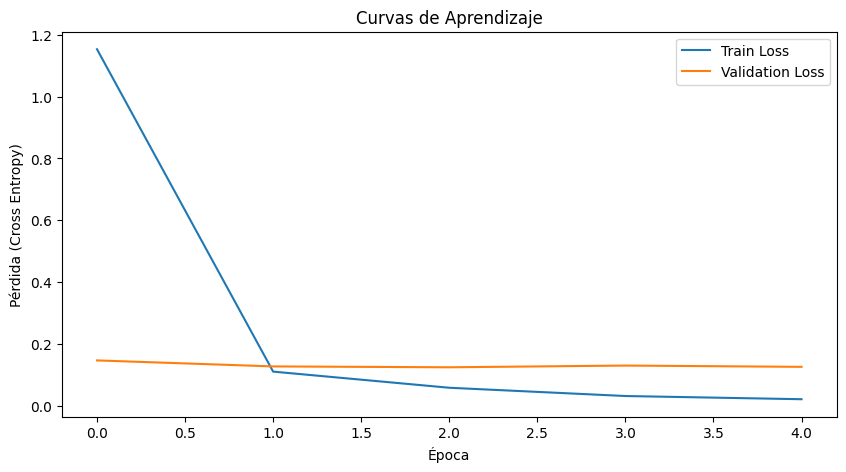

In [95]:
# Graficar curvas de pérdida
if(train_losses and val_losses):
    plt.figure(figsize=(10,5))
    plt.title("Modelo InceptionResnetV1 Fine-Tuned")
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Curvas de Aprendizaje')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Cross Entropy)')
    plt.legend()
    plt.show()

In [96]:
def extract_and_store_embeddings(modelo, loader, store=None, target_names=None, device='cuda', guardar_en_bd=True):
    """
    Función para la extracción de embeddings en lotes (batches).
    Si guardar_en_bd=True, también los almacena en PGVector.
    """
    modelo.eval()
    estado_original_classify = getattr(modelo, 'classify', False)
    modelo.classify = False

    embeddings_list = []
    etiquetas_list = []
    
    global_idx = 0 

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            
            batch_embeddings = modelo(inputs) 
            batch_emb_np = batch_embeddings.cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            embeddings_list.append(batch_emb_np)
            etiquetas_list.append(labels_np)
            
            if guardar_en_bd:
                # Validamos que exista el store y los nombres
                if store is None or target_names is None:
                    raise ValueError("Para guardar en BD necesitas pasar 'store' y 'target_names'.")
                    
                for i in range(len(batch_emb_np)):
                    emb = batch_emb_np[i]
                    label_id = labels_np[i]
                    person_name = target_names[label_id] 
                    
                    record = EmbeddingRecord(
                        id_imagen=str(uuid.uuid4()),
                        embedding=emb.flatten().tolist(), 
                        path=f"{person_name}_loader_{global_idx}.jpg", 
                        etiqueta=person_name,
                        metadata={"source": "LFW DataLoader"}
                    )
                    store.append(record)
                    global_idx += 1
                
    modelo.classify = estado_original_classify
        
    return np.vstack(embeddings_list), np.concatenate(etiquetas_list)

In [97]:
#Extraemos embeddings del modelo sin entrenar
modelo_base = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
print("Evaluando Modelo Base")
#No guardamos los embeddings del modelo base en la BD, solo los extraemos para evaluación inmediata.
#Nos sirven para una comparación directa con el modelo fine-tuned sin popular la base con datos
#con embeddings de un modelo no entrenado
emb_train_base, y_train_base = extract_and_store_embeddings(modelo_base, train_loader, store, train_dataset.target_names, device=device, guardar_en_bd=False) #type: ignore
emb_val_base, y_val_base = extract_and_store_embeddings(modelo_base, val_loader, store, train_dataset.target_names, device=device, guardar_en_bd=False) #type: ignore

# Evaluamos con KNN usando distancia coseno
knn_base = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_base.fit(emb_train_base, y_train_base)
acc_base = accuracy_score(y_val_base, knn_base.predict(emb_val_base))
print(f"Accuracy Modelo BASE: {acc_base*100:.2f}%")

try:
    # Evaluamos el modelo fine-tuned
    print("\nEvaluando Modelo Fine-Tuned")
    #Además de extraer los embeddings, los guardamos en la base de datos para futuras consultas
    emb_train_ft, y_train_ft = extract_and_store_embeddings(model, train_loader, store, train_dataset.target_names, device=device, guardar_en_bd=True) #type: ignore
    emb_val_ft, y_val_ft = extract_and_store_embeddings(model, val_loader, store, train_dataset.target_names, device=device, guardar_en_bd=False) #type: ignore
    # Evaluamos con KNN
    knn_ft = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_ft.fit(emb_train_ft, y_train_ft)
    acc_ft = accuracy_score(y_val_ft, knn_ft.predict(emb_val_ft))
    print(f"🏆 Accuracy Modelo FINE-TUNED: {acc_ft*100:.2f}%")
except Exception as e:
    print(f"No se pudo cargar el modelo fine-tuned: {e}")

Evaluando Modelo Base


Extrayendo embeddings: 100%|██████████| 8/8 [00:03<00:00,  2.06it/s]


Accuracy Modelo BASE: 98.44%

Evaluando Modelo Fine-Tuned


Extrayendo embeddings:   0%|          | 0/36 [00:00<?, ?it/s]

No se pudo cargar el modelo fine-tuned: list index out of range


Calculando Curva ROC para el modelo BASE...


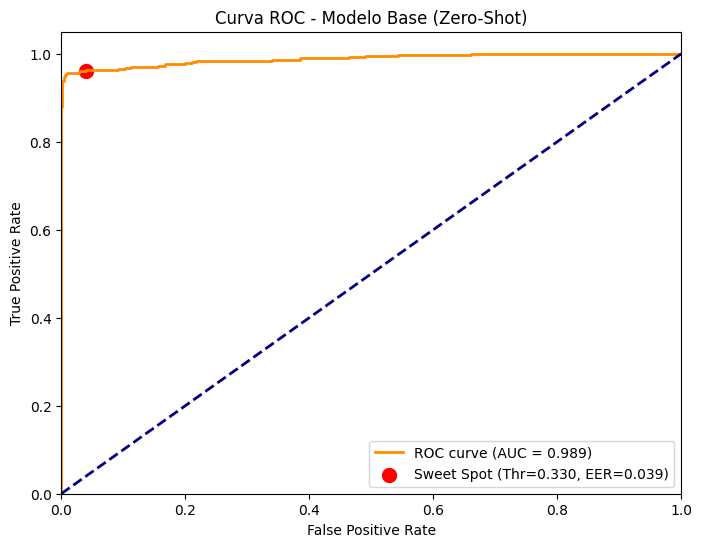

Calculando Curva ROC para el modelo FINE-TUNED...


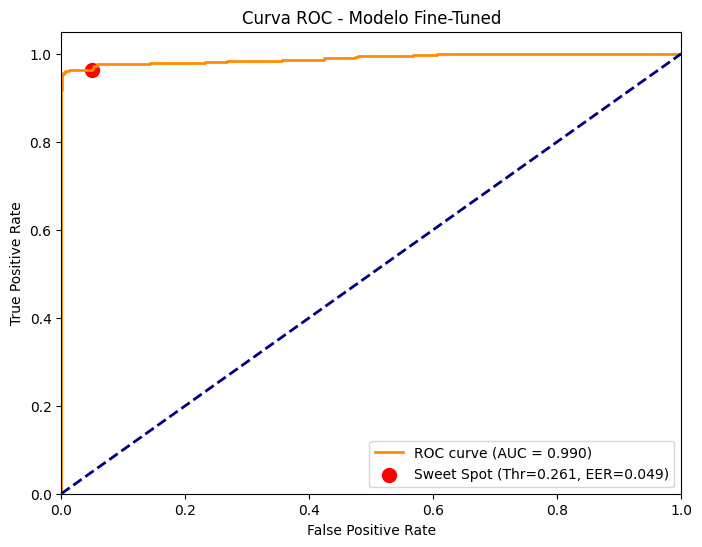

In [98]:
def plot_roc_curve(embeddings, labels, title="Curva ROC"):
    # Calculamos la matriz de similitud coseno completa
    dist_matrix = pairwise_distances(embeddings, metric='cosine')
    sim_matrix = 1 - dist_matrix # Similitud coseno (1 a -1)
    
    y_true = []
    y_scores = []
    
    n = len(labels)
    # Extraemos pares (solo la mitad superior de la matriz para no duplicar)
    for i in range(n):
        for j in range(i+1, n):
            is_same = int(labels[i] == labels[j])
            y_true.append(is_same)
            y_scores.append(sim_matrix[i, j])
            
    # Calculamos FPR, TPR y AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Encontrar el Sweet Spot (Umbral óptimo, EER - Equal Error Rate)
    # Buscamos el punto donde False Positive Rate y False Negative Rate (1-TPR) se cruzan
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.absolute((fnr - fpr)))
    opt_threshold = thresholds[eer_threshold_idx]
    eer = fpr[eer_threshold_idx]
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', s=100, label=f'Sweet Spot (Thr={opt_threshold:.3f}, EER={eer:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Graficar para el modelo Base
print("Calculando Curva ROC para el modelo BASE...")
plot_roc_curve(emb_val_base, y_val_base, title="Curva ROC - Modelo Base (Zero-Shot)")

# Graficar para el modelo Fine-Tuned
if 'emb_val_ft' in locals():
    print("Calculando Curva ROC para el modelo FINE-TUNED...")
    plot_roc_curve(emb_val_ft, y_val_ft, title="Curva ROC - Modelo Fine-Tuned")
